# 🌫️ Air Quality Intelligence
## Data Analytics, Predictive Insights & Decision Support

### AICTE – IBM SkillsBuild Data Analytics with AI Internship

**Project Author:** Ishu  
**Project Domain:** Data Analytics & Artificial Intelligence  
**Dataset Source:** Government of India Open Government Data / Central Pollution Control Board (CPCB)

---

## 📌 Project Overview

Air pollution is a major environmental challenge that requires continuous monitoring and data-driven decision support.

This project analyzes real-world air-quality monitoring data from India to identify pollution patterns, geographic observations, data-quality issues, and unusually high pollutant measurements.

The project combines:

- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Statistical analysis
- Geographic analysis
- Machine Learning
- Predictive pollutant-value estimation
- Data-driven relative pollution-level analysis
- Decision-support recommendations
- Executive-level KPIs and visualizations

The overall analytical workflow follows:

**Data → Information → Insight → Decision → Action**

---

## 🎯 Project Objectives

1. Analyze real-world air-quality monitoring data.
2. Clean and preprocess the dataset.
3. Explore pollutant distributions and geographic coverage.
4. Identify patterns and high-level pollution signals.
5. Build and evaluate machine-learning models.
6. Generate data-driven insights.
7. Develop a decision-support framework for monitoring priorities.
8. Present findings through clear visualizations and KPIs.

---

## 📊 Dataset

The project uses air-quality data published through the Government of India's Open Government Data platform and associated Central Pollution Control Board monitoring data.

The dataset contains information such as:

- State
- City
- Monitoring station
- Date/time
- Latitude
- Longitude
- Pollutant type
- Minimum pollutant value
- Maximum pollutant value
- Average pollutant value

---

## 🤖 Machine Learning Approach

The project evaluates:

- Linear Regression
- Random Forest Regression

The models estimate the recorded pollutant-average value using available location and pollutant-related attributes.

Model performance is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² score

Because the available dataset represents a limited current snapshot rather than a sufficiently long historical time series, this project does **not** claim long-term pollution forecasting.

---

## 🧠 Decision Support

A pollutant-specific percentile framework is used to identify observations that are relatively high within their own pollutant distribution.

These analytical signals are used to support:

- Monitoring prioritization
- Location investigation
- Further data collection
- Pollution-source investigation

The relative-level categories are analytical signals and are **not official AQI categories or health-risk classifications**.

---

## 🌱 Sustainable Development Goals

The project contributes conceptually to:

- **SDG 3 — Good Health and Well-being**
- **SDG 11 — Sustainable Cities and Communities**
- **SDG 13 — Climate Action**

---

## ⚠️ Limitations

- The dataset represents a limited observation period.
- Different pollutants have different measurement units and scales.
- Relative pollution levels should not be interpreted as official AQI classifications.
- The predictive model estimates recorded pollutant values rather than forecasting long-term future pollution.
- Additional historical and meteorological data could improve future forecasting work.

---

## 🚀 Future Scope

Future versions could integrate:

- Longer historical datasets
- Weather and meteorological variables
- Real-time data ingestion
- AQI calculation using official standards
- Time-series forecasting
- Interactive dashboards
- Automated alerts
- Geographic maps and hotspot visualization

---

## 📌 Conclusion

This project demonstrates how real-world environmental data can be transformed into actionable analytical insights using data analytics, machine learning, visualization, and decision-support techniques.

In [3]:
import os

print(os.listdir("/content"))

['.config', 'air_quality_data.csv.xlsx', 'sample_data']


In [4]:
import pandas as pd

file_path = "/content/air_quality_data.csv.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 3542
Columns: 11


,air_quality_data.csv,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Bihar,Samastipur,"DM Office_Kasipur, Samastipur - BSPCB",22-09-2026 18:00:00,25.859655,85.779440,NO2,8.0,9.0,8.0
1,India,Bihar,Sasaram,"Dada Peer, Sasaram - BSPCB",22-09-2026 18:00:00,24.952822,84.002396,PM2.5,3.0,22.0,12.0
2,India,Bihar,Sasaram,"Dada Peer, Sasaram - BSPCB",22-09-2026 18:00:00,24.952822,84.002396,NH3,NaN,NaN,NaN
3,India,Bihar,Siwan,"Chitragupta Nagar, Siwan - BSPCB",22-09-2026 18:00:00,26.227166,84.357043,NO2,2.0,2.0,2.0
4,India,Bihar,Siwan,"Chitragupta Nagar, Siwan - BSPCB",22-09-2026 18:00:00,26.227166,84.357043,NH3,1.0,1.0,1.0


In [5]:
# ============================================
# STEP 2: DATASET PROFILE
# ============================================

print("=" * 70)
print("AIR QUALITY DATASET PROFILE")
print("=" * 70)

# 1. Dataset dimensions
print(f"\nTotal Rows    : {df.shape[0]:,}")
print(f"Total Columns : {df.shape[1]}")

# 2. Column names and data types
print("\n--- COLUMN INFORMATION ---")
column_info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Values": df.notna().sum().values,
    "Missing Values": df.isna().sum().values
})

display(column_info)

# 3. Duplicate records
print("\n--- DUPLICATE RECORDS ---")
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")

# 4. Missing-value analysis
print("\n--- MISSING VALUE ANALYSIS ---")

missing_report = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
})

missing_report = missing_report.sort_values(
    "Missing %",
    ascending=False
)

display(missing_report)

# 5. Unique values
print("\n--- UNIQUE VALUES ---")

for column in df.columns:
    print(f"{column}: {df[column].nunique(dropna=True):,} unique values")

# 6. Numeric statistics
print("\n--- NUMERICAL STATISTICS ---")
display(df.describe().T)

# 7. First and last records
print("\n--- FIRST 5 RECORDS ---")
display(df.head())

print("\n--- LAST 5 RECORDS ---")
display(df.tail())

AIR QUALITY DATASET PROFILE

Total Rows    : 3,542
Total Columns : 11

--- COLUMN INFORMATION ---


,Column,Data Type,Non-Null Values,Missing Values
air_quality_data.csv,air_quality_data.csv,object,3542,0
state,state,object,3542,0
city,city,object,3542,0
station,station,object,3542,0
last_update,last_update,object,3542,0
latitude,latitude,float64,3542,0
longitude,longitude,float64,3542,0
pollutant_id,pollutant_id,object,3542,0
pollutant_min,pollutant_min,float64,3194,348
pollutant_max,pollutant_max,float64,3194,348



--- DUPLICATE RECORDS ---
Duplicate rows: 0

--- MISSING VALUE ANALYSIS ---


,Missing Count,Missing %
pollutant_min,348,9.82
pollutant_avg,348,9.82
pollutant_max,348,9.82
city,0,0.00
state,0,0.00
air_quality_data.csv,0,0.00
station,0,0.00
longitude,0,0.00
latitude,0,0.00
last_update,0,0.00



--- UNIQUE VALUES ---
air_quality_data.csv: 1 unique values
state: 30 unique values
city: 264 unique values
station: 506 unique values
last_update: 1 unique values
latitude: 506 unique values
longitude: 506 unique values
pollutant_id: 7 unique values
pollutant_min: 148 unique values
pollutant_max: 310 unique values
pollutant_avg: 211 unique values

--- NUMERICAL STATISTICS ---


,count,mean,std,min,25%,50%,75%,max
latitude,3542.0,23.461460,5.029111,8.514909,19.230757,23.827669,28.207266,34.147096
longitude,3542.0,78.437968,4.823985,70.776774,75.244448,77.272783,80.413302,94.636574
pollutant_min,3194.0,24.832812,27.745526,0.000000,6.000000,16.000000,32.000000,240.000000
pollutant_max,3194.0,60.069505,72.846901,0.000000,14.000000,35.000000,75.000000,500.000000
pollutant_avg,3194.0,39.024734,43.151221,0.000000,10.000000,26.000000,51.000000,420.000000



--- FIRST 5 RECORDS ---


,air_quality_data.csv,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Bihar,Samastipur,"DM Office_Kasipur, Samastipur - BSPCB",22-09-2026 18:00:00,25.859655,85.779440,NO2,8.0,9.0,8.0
1,India,Bihar,Sasaram,"Dada Peer, Sasaram - BSPCB",22-09-2026 18:00:00,24.952822,84.002396,PM2.5,3.0,22.0,12.0
2,India,Bihar,Sasaram,"Dada Peer, Sasaram - BSPCB",22-09-2026 18:00:00,24.952822,84.002396,NH3,NaN,NaN,NaN
3,India,Bihar,Siwan,"Chitragupta Nagar, Siwan - BSPCB",22-09-2026 18:00:00,26.227166,84.357043,NO2,2.0,2.0,2.0
4,India,Bihar,Siwan,"Chitragupta Nagar, Siwan - BSPCB",22-09-2026 18:00:00,26.227166,84.357043,NH3,1.0,1.0,1.0



--- LAST 5 RECORDS ---


,air_quality_data.csv,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
3537,India,West Bengal,Kolkata,"Victoria, Kolkata - WBPCB",22-09-2026 18:00:00,22.544808,88.340369,PM10,15.0,63.0,28.0
3538,India,West Bengal,Kolkata,"Victoria, Kolkata - WBPCB",22-09-2026 18:00:00,22.544808,88.340369,SO2,0.0,9.0,4.0
3539,India,West Bengal,Kolkata,"Rabindra Sarobar, Kolkata - WBPCB",22-09-2026 18:00:00,22.511060,88.351420,PM10,20.0,29.0,23.0
3540,India,West Bengal,Kolkata,"Bidhannagar, Kolkata - WBPCB",22-09-2026 18:00:00,22.581570,88.410025,NO2,7.0,14.0,13.0
3541,India,West Bengal,Kolkata,"Bidhannagar, Kolkata - WBPCB",22-09-2026 18:00:00,22.581570,88.410025,CO,26.0,28.0,27.0


In [6]:
# ============================================
# STEP 3: POLLUTANT & LOCATION ANALYSIS
# ============================================

print("=" * 70)
print("POLLUTANT & LOCATION ANALYSIS")
print("=" * 70)

# 1. Check pollutant types
print("\n--- POLLUTANT TYPES ---")

if "pollutant_id" in df.columns:
    pollutants = df["pollutant_id"].dropna().unique()
    print("Pollutants found:")
    for p in sorted(pollutants):
        print("•", p)
else:
    print("pollutant_id column not found.")

# 2. Number of states, cities and stations
print("\n--- GEOGRAPHICAL COVERAGE ---")

for column in ["state", "city", "station"]:
    if column in df.columns:
        print(
            f"{column.title()}s: "
            f"{df[column].nunique(dropna=True):,}"
        )

# 3. Geographic coverage
if "state" in df.columns:
    print("\nTop 15 states by number of records:")
    display(df["state"].value_counts().head(15))

if "city" in df.columns:
    print("\nTop 15 cities by number of records:")
    display(df["city"].value_counts().head(15))

# 4. Pollutant measurement statistics
measurement_columns = [
    "pollutant_min",
    "pollutant_max",
    "pollutant_avg"
]

available_measurements = [
    col for col in measurement_columns
    if col in df.columns
]

print("\n--- POLLUTANT MEASUREMENT STATISTICS ---")

if available_measurements:
    display(df[available_measurements].describe().T)

# 5. Average pollutant concentration by pollutant
if "pollutant_id" in df.columns and "pollutant_avg" in df.columns:

    print("\n--- AVERAGE VALUE BY POLLUTANT ---")

    pollutant_summary = (
        df.groupby("pollutant_id")["pollutant_avg"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
        .sort_values("mean", ascending=False)
    )

    display(pollutant_summary)

# 6. Missing values in pollutant measurements
print("\n--- MISSING POLLUTANT MEASUREMENTS ---")

if available_measurements:
    pollutant_missing = pd.DataFrame({
        "Missing Count": df[available_measurements].isna().sum(),
        "Missing %": (
            df[available_measurements].isna().mean() * 100
        ).round(2)
    })

    display(pollutant_missing)

# 7. Check suspicious negative measurements
print("\n--- NEGATIVE MEASUREMENTS ---")

for col in available_measurements:
    negative_count = (df[col] < 0).sum()
    print(f"{col}: {negative_count:,} negative values")


POLLUTANT & LOCATION ANALYSIS

--- POLLUTANT TYPES ---
Pollutants found:
• CO
• NH3
• NO2
• OZONE
• PM10
• PM2.5
• SO2

--- GEOGRAPHICAL COVERAGE ---
States: 30
Citys: 264
Stations: 506

Top 15 states by number of records:


,count
state,
Maharashtra,630
Uttar Pradesh,462
Rajasthan,329
Delhi,315
Haryana,210
Bihar,203
Karnataka,175
Madhya Pradesh,161
West Bengal,154



Top 15 cities by number of records:


,count
city,
Delhi,315
Mumbai,175
Hyderabad,98
Bengaluru,63
Ahmedabad,56
Pimpri-Chinchwad,49
Pune,49
Ghaziabad,49
Kolkata,49



--- POLLUTANT MEASUREMENT STATISTICS ---


...


--- AVERAGE VALUE BY POLLUTANT ---


,count,mean,median,min,max
pollutant_id,,,,,
PM10,450,83.17,69.0,10.0,366.0
PM2.5,454,72.97,54.0,2.0,420.0
OZONE,484,38.68,28.0,1.0,264.0
CO,484,34.37,30.0,2.0,194.0
NO2,468,23.30,20.0,0.0,167.0
SO2,437,13.17,10.0,0.0,98.0
NH3,417,4.99,4.0,0.0,29.0



--- MISSING POLLUTANT MEASUREMENTS ---


,Missing Count,Missing %
pollutant_min,348,9.82
pollutant_max,348,9.82
pollutant_avg,348,9.82



--- NEGATIVE MEASUREMENTS ---
pollutant_min: 0 negative values
pollutant_max: 0 negative values
pollutant_avg: 0 negative values


In [7]:
# ============================================
# STEP 4: DATE/TIME & POLLUTION TREND ANALYSIS
# ============================================

print("=" * 70)
print("DATE/TIME & POLLUTION TREND ANALYSIS")
print("=" * 70)

# Make a copy so the original dataframe remains unchanged
analysis_df = df.copy()

# ------------------------------------------------
# 1. Convert last_update to datetime
# ------------------------------------------------

if "last_update" in analysis_df.columns:

    analysis_df["last_update"] = pd.to_datetime(
        analysis_df["last_update"],
        errors="coerce"
    )

    print("\n--- DATE RANGE ---")

    print("Earliest record:",
          analysis_df["last_update"].min())

    print("Latest record:",
          analysis_df["last_update"].max())

    print("Invalid/unreadable dates:",
          analysis_df["last_update"].isna().sum())

    # ------------------------------------------------
    # 2. Extract time features
    # ------------------------------------------------

    analysis_df["year"] = analysis_df["last_update"].dt.year
    analysis_df["month"] = analysis_df["last_update"].dt.month
    analysis_df["month_name"] = analysis_df["last_update"].dt.month_name()
    analysis_df["day"] = analysis_df["last_update"].dt.day
    analysis_df["hour"] = analysis_df["last_update"].dt.hour
    analysis_df["day_of_week"] = analysis_df["last_update"].dt.day_name()

    print("\n--- RECORDS BY YEAR ---")
    display(analysis_df["year"].value_counts().sort_index())

    print("\n--- RECORDS BY MONTH ---")
    display(analysis_df["month_name"].value_counts())

    print("\n--- RECORDS BY HOUR ---")
    display(analysis_df["hour"].value_counts().sort_index())

else:
    print("last_update column was not found.")

# ------------------------------------------------
# 3. Convert pollutant_avg to numeric
# ------------------------------------------------

if "pollutant_avg" in analysis_df.columns:

    analysis_df["pollutant_avg"] = pd.to_numeric(
        analysis_df["pollutant_avg"],
        errors="coerce"
    )

# ------------------------------------------------
# 4. Average pollution by pollutant
# ------------------------------------------------

if "pollutant_id" in analysis_df.columns:

    print("\n--- OVERALL POLLUTANT AVERAGES ---")

    overall_pollution = (
        analysis_df
        .groupby("pollutant_id")["pollutant_avg"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    display(overall_pollution)

# ------------------------------------------------
# 5. Monthly pollution trend
# ------------------------------------------------

if all(
    col in analysis_df.columns
    for col in ["month", "pollutant_id", "pollutant_avg"]
):

    monthly_pollution = (
        analysis_df
        .groupby(["month", "pollutant_id"])["pollutant_avg"]
        .mean()
        .reset_index()
    )

    print("\n--- MONTHLY POLLUTION TREND ---")
    display(monthly_pollution.head(20))

# ------------------------------------------------
# 6. City-level pollution
# ------------------------------------------------

if all(
    col in analysis_df.columns
    for col in ["city", "pollutant_avg"]
):

    print("\n--- TOP CITIES BY AVERAGE POLLUTANT VALUE ---")

    city_pollution = (
        analysis_df
        .groupby("city")["pollutant_avg"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .round(2)
    )

    display(city_pollution)

print("\nSTEP 4 COMPLETED.")

DATE/TIME & POLLUTION TREND ANALYSIS

--- DATE RANGE ---
Earliest record: 2026-09-22 18:00:00
Latest record: 2026-09-22 18:00:00
Invalid/unreadable dates: 0

--- RECORDS BY YEAR ---


/tmp/ipykernel_1368/2568479303.py:18: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  analysis_df["last_update"] = pd.to_datetime(


,count
year,
2026,3542



--- RECORDS BY MONTH ---


,count
month_name,
September,3542


...


--- MONTHLY POLLUTION TREND ---


,month,pollutant_id,pollutant_avg
0,9,CO,34.365702
1,9,NH3,4.988010
2,9,NO2,23.299145
3,9,OZONE,38.679752
4,9,PM10,83.166667
5,9,PM2.5,72.969163
6,9,SO2,13.167048



--- TOP CITIES BY AVERAGE POLLUTANT VALUE ---


,pollutant_avg
city,
Leh,143.67
Khora,130.00
Gurugram,92.25
Noida,90.67
Gajraula,84.83
Greater Noida,79.69
Modinagar,79.43
Meerut,73.24
Delhi,72.81



STEP 4 COMPLETED.


In [8]:
# ============================================
# STEP 5: DATA CLEANING & QUALITY CONTROL
# ============================================

import numpy as np
print("=" * 70)
print("DATA CLEANING & QUALITY CONTROL")
print("=" * 70)

# Work on a copy
clean_df = analysis_df.copy()

# ------------------------------------------------
# 1. Remove completely empty rows
# ------------------------------------------------

before_rows = len(clean_df)

clean_df = clean_df.dropna(how="all")

after_empty_rows = len(clean_df)

print(f"\nCompletely empty rows removed: "
      f"{before_rows - after_empty_rows:,}")

# ------------------------------------------------
# 2. Standardize column names
# ------------------------------------------------

clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nStandardized columns:")
print(clean_df.columns.tolist())

# ------------------------------------------------
# 3. Remove duplicate records
# ------------------------------------------------

before_duplicates = len(clean_df)

clean_df = clean_df.drop_duplicates()

after_duplicates = len(clean_df)

print(f"\nDuplicate rows removed: "
      f"{before_duplicates - after_duplicates:,}")

# ------------------------------------------------
# 4. Convert pollutant measurements to numeric
# ------------------------------------------------

measurement_columns = [
    "pollutant_min",
    "pollutant_max",
    "pollutant_avg"
]

for column in measurement_columns:
    if column in clean_df.columns:
        clean_df[column] = pd.to_numeric(
            clean_df[column],
            errors="coerce"
        )

# ------------------------------------------------
# 5. Check negative measurements
# ------------------------------------------------

print("\n--- NEGATIVE VALUES ---")

for column in measurement_columns:
    if column in clean_df.columns:
        negative_count = (clean_df[column] < 0).sum()
        print(f"{column}: {negative_count:,}")

# Replace physically impossible negative measurements
# with missing values rather than inventing values.

for column in measurement_columns:
    if column in clean_df.columns:
        clean_df.loc[
            clean_df[column] < 0,
            column
        ] = np.nan

# ------------------------------------------------
# 6. Check logical consistency
# pollutant_min <= pollutant_avg <= pollutant_max
# ------------------------------------------------

if all(
    column in clean_df.columns
    for column in measurement_columns
):

    inconsistent = (
        (clean_df["pollutant_min"] > clean_df["pollutant_avg"]) |
        (clean_df["pollutant_avg"] > clean_df["pollutant_max"])
    )

    print("\nLogically inconsistent measurements:",
          inconsistent.sum())

# ------------------------------------------------
# 7. Clean text fields
# ------------------------------------------------

text_columns = [
    "country",
    "state",
    "city",
    "station",
    "pollutant_id"
]

for column in text_columns:
    if column in clean_df.columns:
        clean_df[column] = (
            clean_df[column]
            .astype("string")
            .str.strip()
        )

# ------------------------------------------------
# 8. Final missing-value report
# ------------------------------------------------

print("\n--- FINAL MISSING VALUE REPORT ---")

final_missing = pd.DataFrame({
    "Missing Count": clean_df.isna().sum(),
    "Missing %": (
        clean_df.isna().mean() * 100
    ).round(2)
})

display(
    final_missing
    .sort_values("Missing %", ascending=False)
)

# ------------------------------------------------
# 9. Dataset size after cleaning
# ------------------------------------------------

print("\n--- CLEAN DATASET SUMMARY ---")

print(f"Original rows : {df.shape[0]:,}")
print(f"Clean rows    : {clean_df.shape[0]:,}")
print(f"Columns       : {clean_df.shape[1]:,}")

print("\nData cleaning completed successfully.")

DATA CLEANING & QUALITY CONTROL

Completely empty rows removed: 0

Standardized columns:
['air_quality_data.csv', 'state', 'city', 'station', 'last_update', 'latitude', 'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max', 'pollutant_avg', 'year', 'month', 'month_name', 'day', 'hour', 'day_of_week']

Duplicate rows removed: 0

--- NEGATIVE VALUES ---
pollutant_min: 0
pollutant_max: 0
pollutant_avg: 0

Logically inconsistent measurements: 0

--- FINAL MISSING VALUE REPORT ---


,Missing Count,Missing %
pollutant_min,348,9.82
pollutant_avg,348,9.82
pollutant_max,348,9.82
air_quality_data.csv,0,0.00
state,0,0.00
last_update,0,0.00
latitude,0,0.00
station,0,0.00
city,0,0.00
pollutant_id,0,0.00



--- CLEAN DATASET SUMMARY ---
Original rows : 3,542
Clean rows    : 3,542
Columns       : 17

Data cleaning completed successfully.


EXPLORATORY DATA ANALYSIS


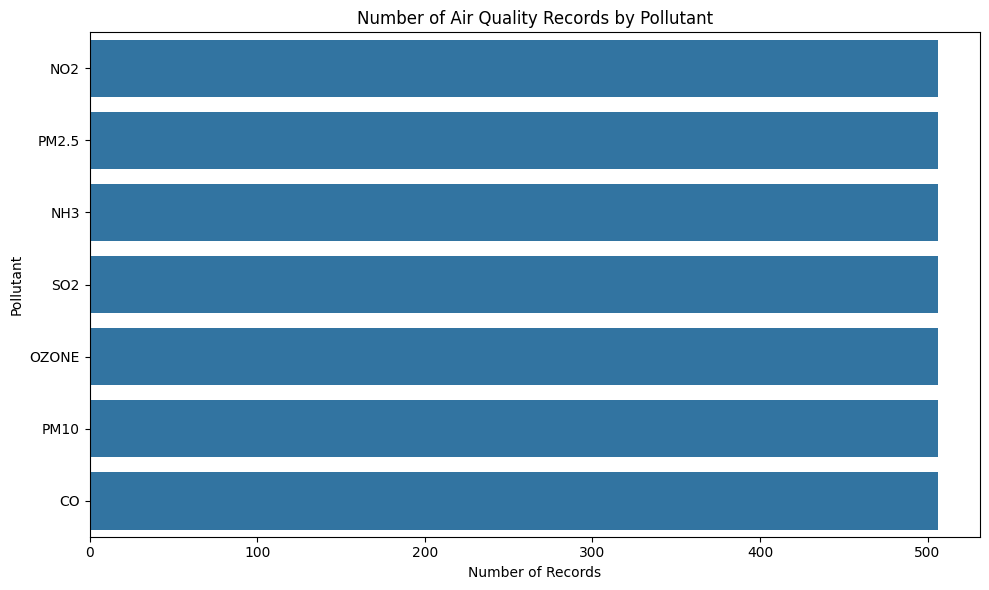

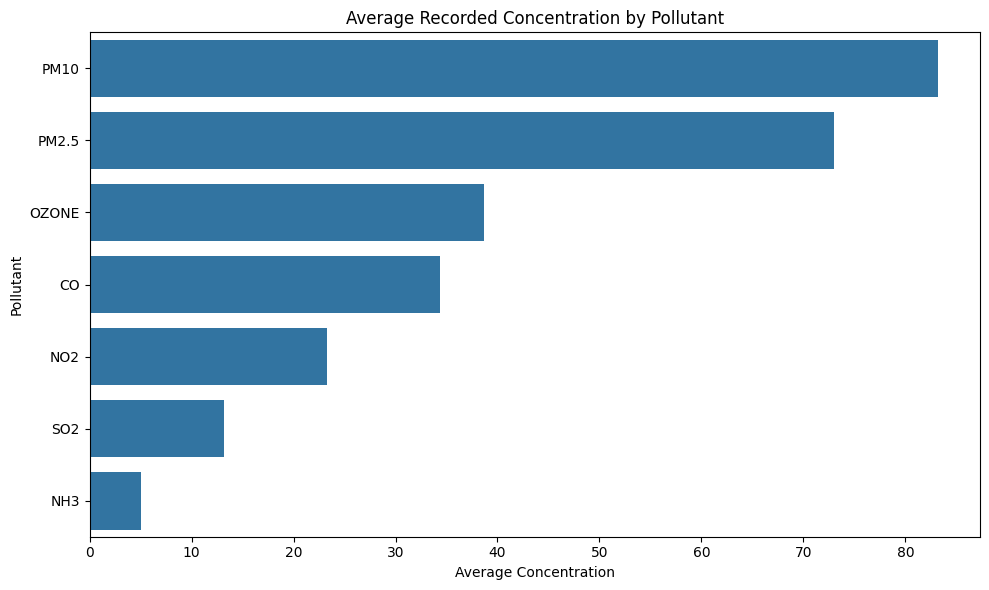

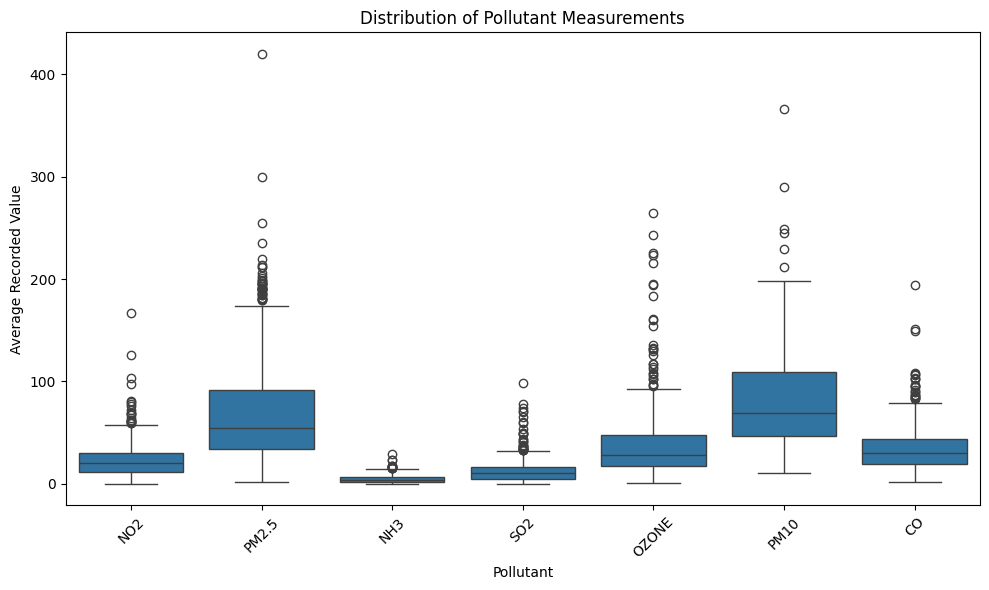

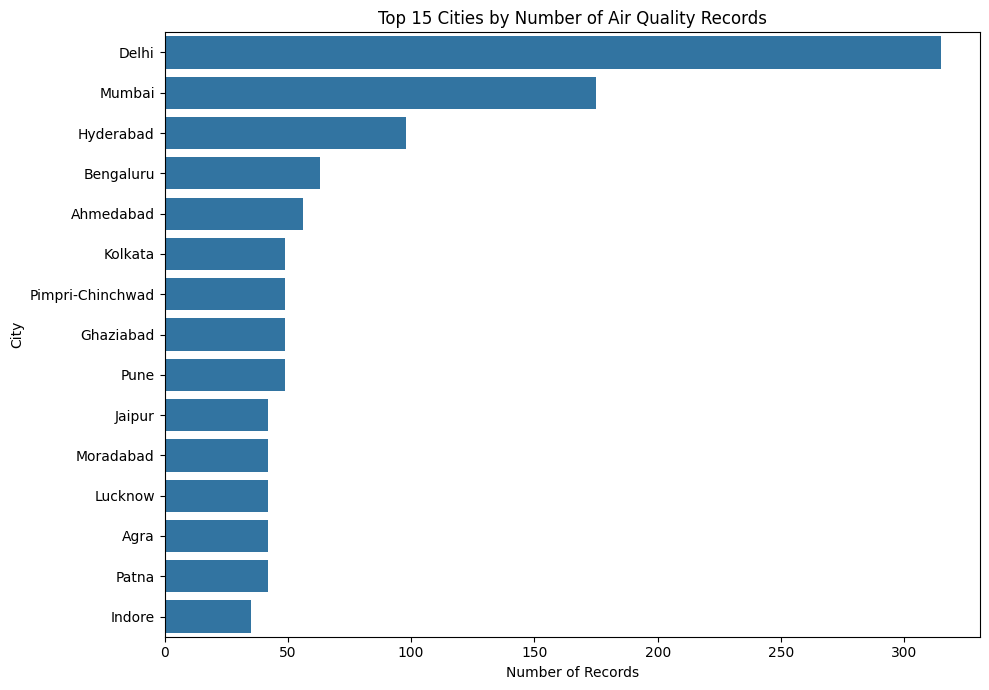

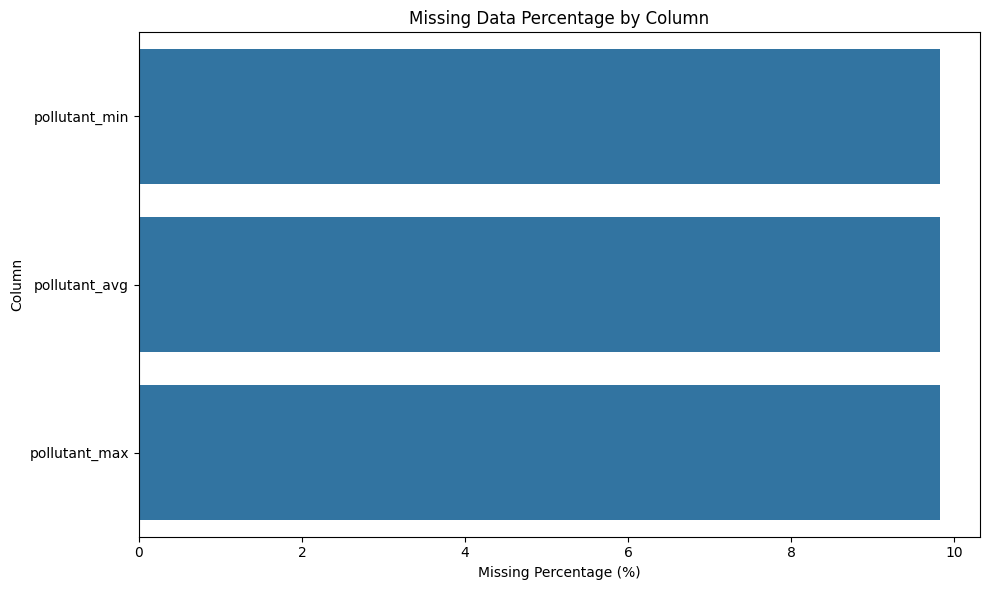


EDA visualizations completed successfully.


In [9]:
# ============================================
# STEP 6: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# ------------------------------------------------
# 1. Pollutant distribution
# ------------------------------------------------

plt.figure(figsize=(10, 6))

pollutant_counts = clean_df["pollutant_id"].value_counts()

sns.barplot(
    x=pollutant_counts.values,
    y=pollutant_counts.index
)

plt.title("Number of Air Quality Records by Pollutant")
plt.xlabel("Number of Records")
plt.ylabel("Pollutant")
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 2. Average pollutant concentration
# ------------------------------------------------

pollutant_avg = (
    clean_df
    .groupby("pollutant_id")["pollutant_avg"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=pollutant_avg.values,
    y=pollutant_avg.index
)

plt.title("Average Recorded Concentration by Pollutant")
plt.xlabel("Average Concentration")
plt.ylabel("Pollutant")
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 3. Pollution distribution
# ------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clean_df,
    x="pollutant_id",
    y="pollutant_avg"
)

plt.title("Distribution of Pollutant Measurements")
plt.xlabel("Pollutant")
plt.ylabel("Average Recorded Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 4. Top cities by number of observations
# ------------------------------------------------

top_cities = clean_df["city"].value_counts().head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 15 Cities by Number of Air Quality Records")
plt.xlabel("Number of Records")
plt.ylabel("City")
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 5. Missing-value visualization
# ------------------------------------------------

missing_percentage = (
    clean_df.isna().mean() * 100
).sort_values(ascending=False)

missing_percentage = missing_percentage[
    missing_percentage > 0
]

if len(missing_percentage) > 0:

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=missing_percentage.values,
        y=missing_percentage.index
    )

    plt.title("Missing Data Percentage by Column")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

else:
    print("\nNo missing values found in the cleaned dataset.")


print("\nEDA visualizations completed successfully.")

TIME-BASED POLLUTION TRENDS


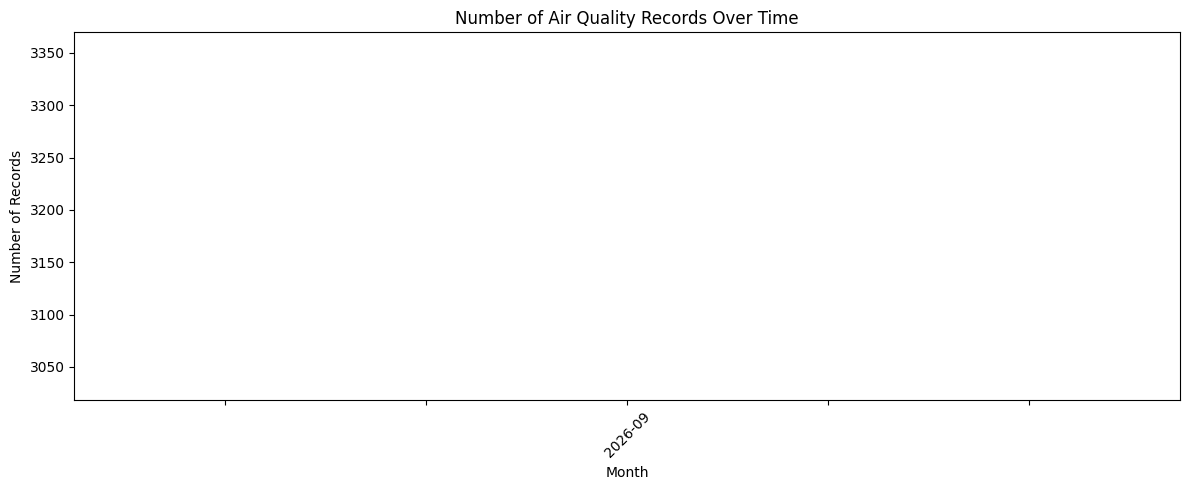

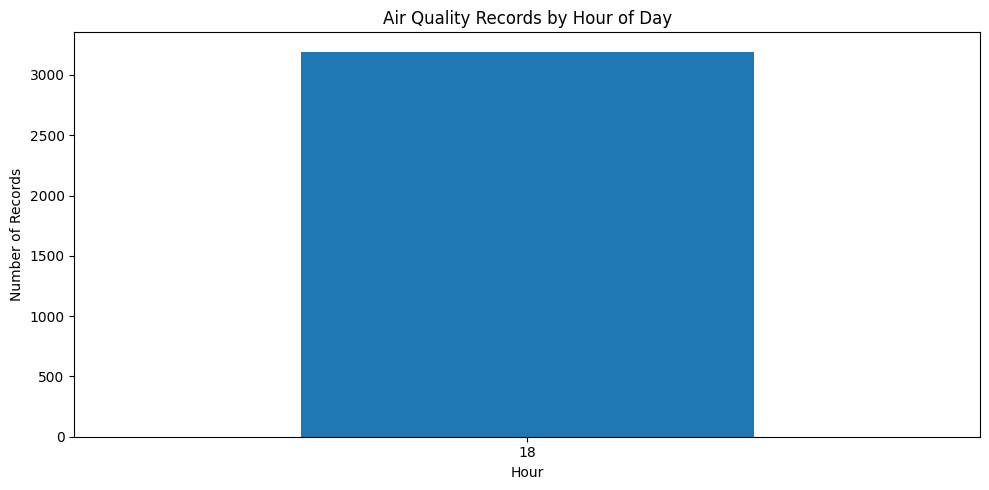

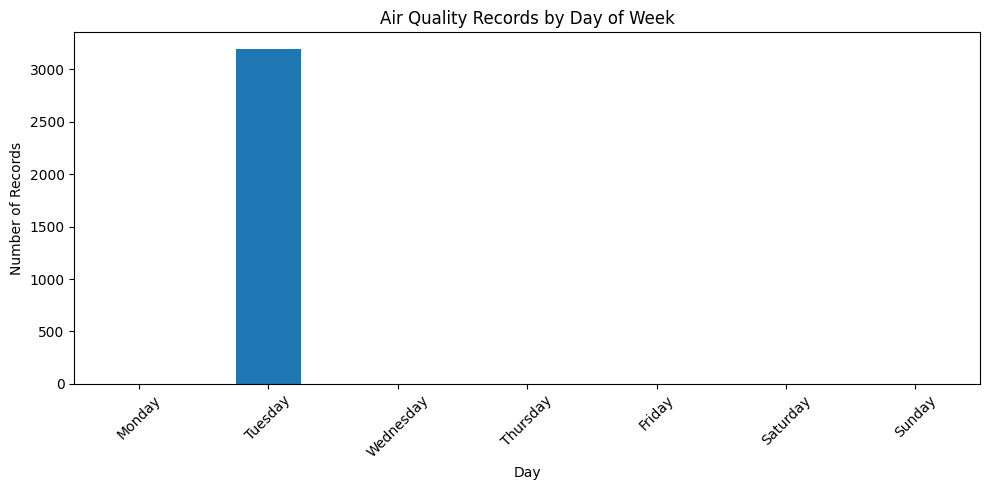

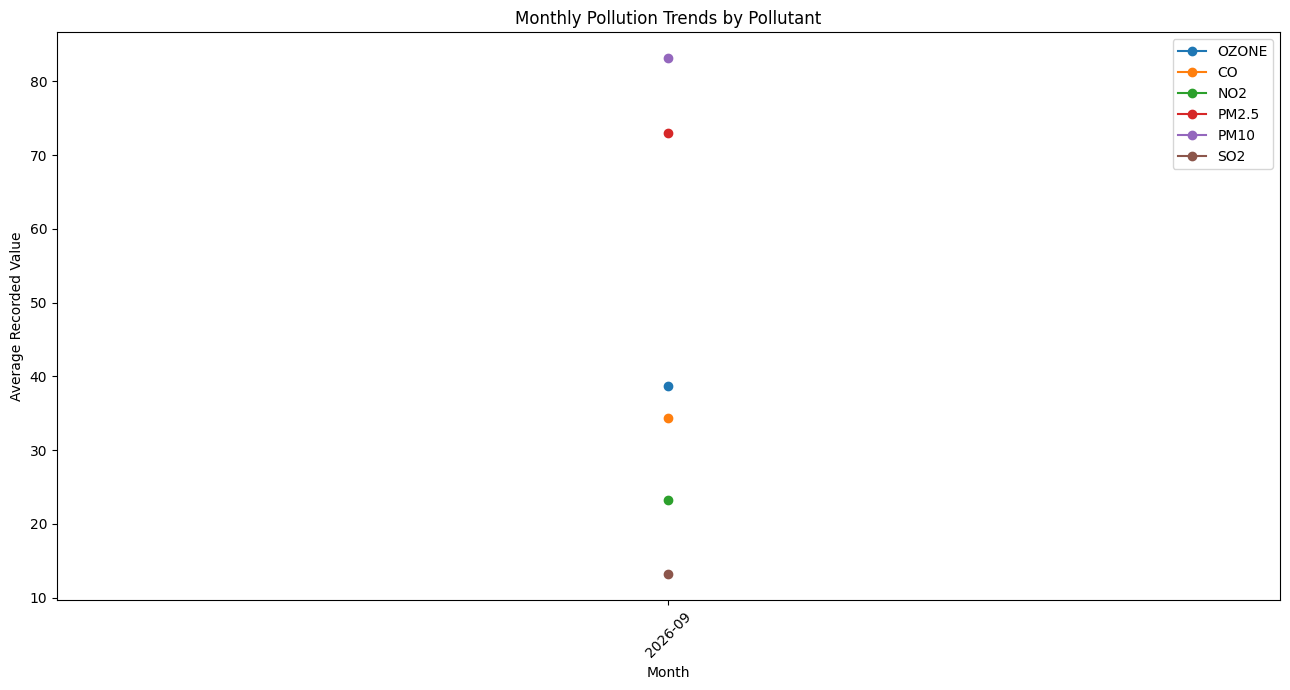


STEP 7 COMPLETED.


In [10]:
# ============================================
# STEP 7: TIME-BASED POLLUTION TRENDS
# ============================================

print("=" * 70)
print("TIME-BASED POLLUTION TRENDS")
print("=" * 70)

# Make sure date column is datetime
clean_df["last_update"] = pd.to_datetime(
    clean_df["last_update"],
    errors="coerce"
)

# Remove rows without valid dates for time analysis
trend_df = clean_df.dropna(
    subset=["last_update", "pollutant_avg"]
).copy()

# Create time features
trend_df["year_month"] = trend_df["last_update"].dt.to_period("M").astype(str)
trend_df["hour"] = trend_df["last_update"].dt.hour
trend_df["day_of_week"] = trend_df["last_update"].dt.day_name()

# ------------------------------------------------
# 1. Monthly number of observations
# ------------------------------------------------

monthly_records = trend_df.groupby(
    "year_month"
).size()

plt.figure(figsize=(12, 5))

monthly_records.plot()

plt.title("Number of Air Quality Records Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 2. Hourly observation pattern
# ------------------------------------------------

hourly_records = trend_df.groupby(
    "hour"
).size()

plt.figure(figsize=(10, 5))

hourly_records.plot(kind="bar")

plt.title("Air Quality Records by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 3. Day-of-week observation pattern
# ------------------------------------------------

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_records = (
    trend_df["day_of_week"]
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))

day_records.plot(kind="bar")

plt.title("Air Quality Records by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 4. Monthly trend for individual pollutants
# ------------------------------------------------

top_pollutants = (
    trend_df["pollutant_id"]
    .value_counts()
    .head(6)
    .index
)

plt.figure(figsize=(13, 7))

for pollutant in top_pollutants:

    temp = trend_df[
        trend_df["pollutant_id"] == pollutant
    ]

    monthly_avg = (
        temp.groupby("year_month")["pollutant_avg"]
        .mean()
    )

    plt.plot(
        monthly_avg.index,
        monthly_avg.values,
        marker="o",
        label=pollutant
    )

plt.title("Monthly Pollution Trends by Pollutant")
plt.xlabel("Month")
plt.ylabel("Average Recorded Value")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


print("\nSTEP 7 COMPLETED.")

GEOGRAPHIC POLLUTION HOTSPOT ANALYSIS


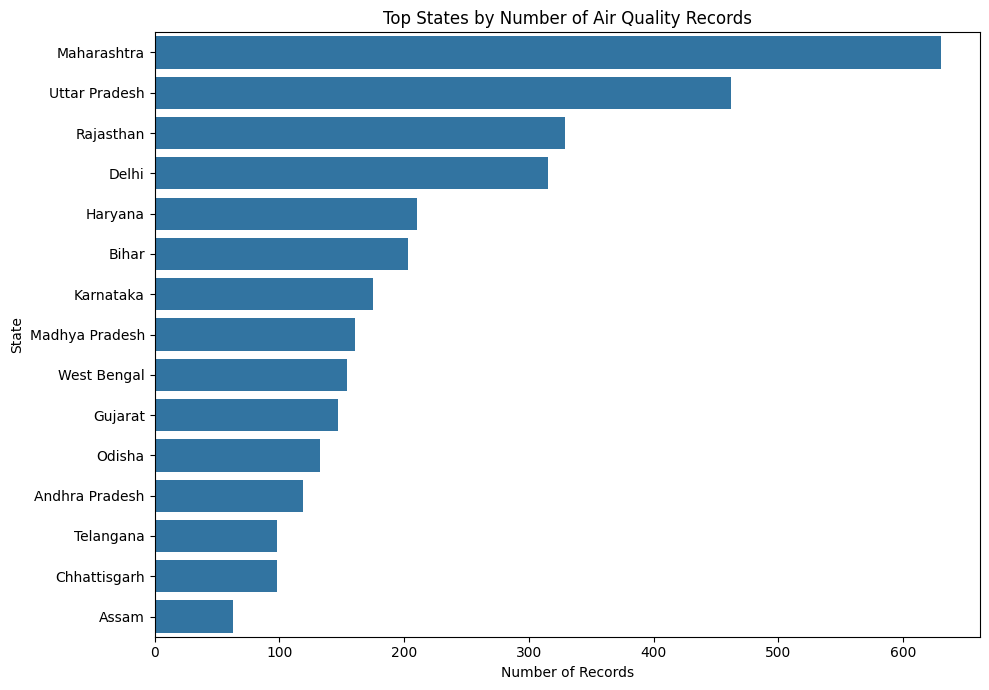


--- TOP CITIES BY AVERAGE PM2.5 ---


,Average PM2.5
city,
Khora,300.000000
Gurugram,235.750000
Greater Noida,235.000000
Manesar,203.000000
Mandi Gobindgarh,196.000000
Fatehpur Sikri,195.000000
Yamuna Nagar,191.000000
Bahadurgarh,190.000000
Mathura,189.000000


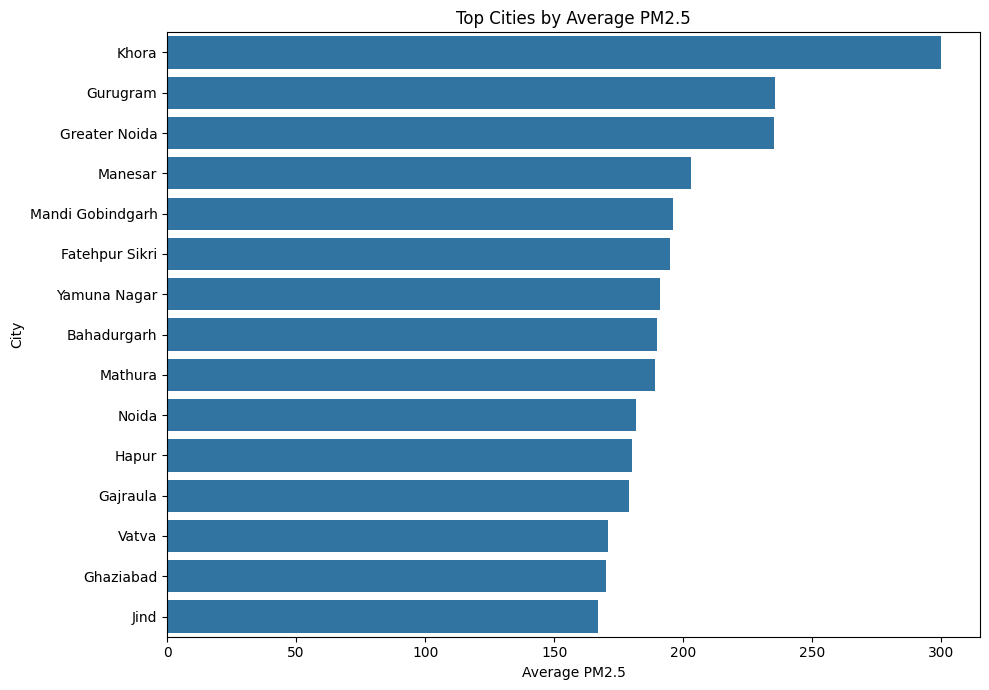


--- TOP CITIES BY AVERAGE PM10 ---


,Average PM10
city,
Saharsa,245.00000
Greater Noida,229.00000
Gurugram,194.00000
Noida,183.75000
Baghpat,177.00000
Khora,175.00000
Pithampur,165.00000
Mathura,162.00000
Delhi,159.97561


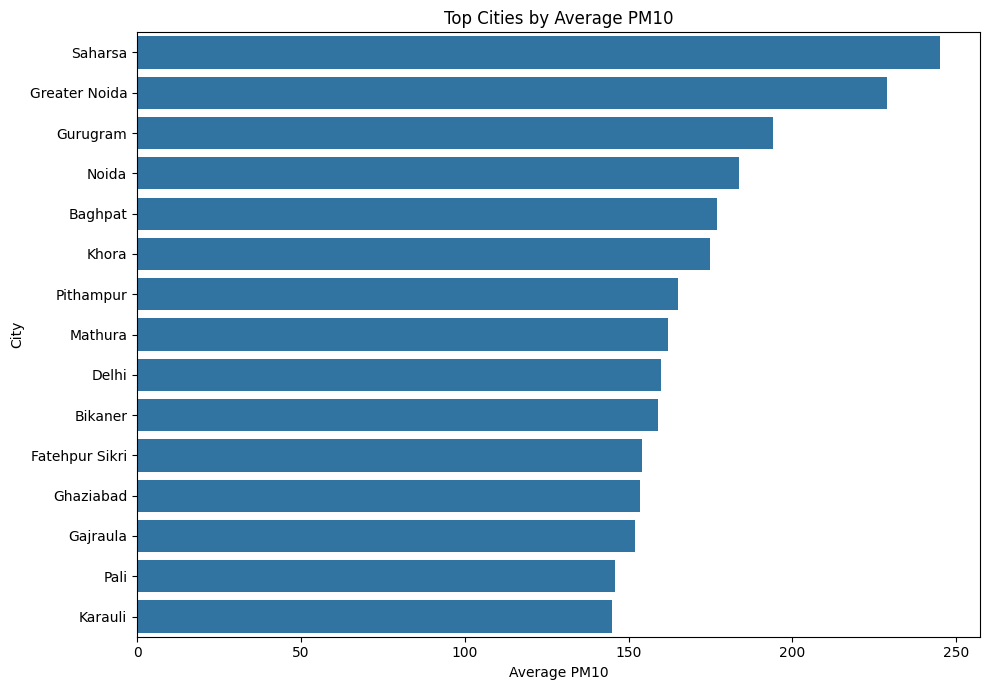


--- TOP MONITORING STATIONS BY PM2.5 ---


,Average PM2.5
station,
"Vikas Sadan, Gurugram - HSPCB",420.0
"Prashant Garden, Khora - UPPCB",300.0
"Chandni Chowk, Delhi - IITM",255.0
"Knowledge Park - V, Greater Noida - UPPCB",235.0
"Teri Gram, Gurugram - HSPCB",220.0
"Loni, Ghaziabad - UPPCB",214.0
"Anand Vihar, Delhi - DPCC",212.0
"Sector - 62, Noida - IITM",212.0
"Sonia Vihar, Delhi - DPCC",206.0



--- LOCATION-POLLUTANT SUMMARY ---


,state,city,pollutant_id,observations,average,median,maximum
0,Andhra Pradesh,Amaravati,CO,1,32.0,32.0,32.0
1,Andhra Pradesh,Amaravati,NH3,1,4.0,4.0,4.0
2,Andhra Pradesh,Amaravati,NO2,1,26.0,26.0,26.0
3,Andhra Pradesh,Amaravati,OZONE,1,49.0,49.0,49.0
4,Andhra Pradesh,Amaravati,PM10,1,99.0,99.0,99.0
5,Andhra Pradesh,Amaravati,PM2.5,1,67.0,67.0,67.0
6,Andhra Pradesh,Amaravati,SO2,0,NaN,NaN,NaN
7,Andhra Pradesh,Anantapur,CO,1,37.0,37.0,37.0
8,Andhra Pradesh,Anantapur,NH3,1,3.0,3.0,3.0
9,Andhra Pradesh,Anantapur,NO2,1,20.0,20.0,20.0



STEP 8 COMPLETED.


In [11]:
# ============================================
# STEP 8: GEOGRAPHIC POLLUTION HOTSPOT ANALYSIS
# ============================================

print("=" * 70)
print("GEOGRAPHIC POLLUTION HOTSPOT ANALYSIS")
print("=" * 70)

# ------------------------------------------------
# 1. Number of records by state
# ------------------------------------------------

state_records = (
    clean_df["state"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=state_records.values,
    y=state_records.index
)

plt.title("Top States by Number of Air Quality Records")
plt.xlabel("Number of Records")
plt.ylabel("State")
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 2. Top cities by PM2.5
# ------------------------------------------------

pm25_df = clean_df[
    clean_df["pollutant_id"].astype(str).str.upper() == "PM2.5"
].copy()

if not pm25_df.empty:

    city_pm25 = (
        pm25_df
        .groupby("city")["pollutant_avg"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    print("\n--- TOP CITIES BY AVERAGE PM2.5 ---")
    display(city_pm25.to_frame("Average PM2.5"))

    plt.figure(figsize=(10, 7))

    sns.barplot(
        x=city_pm25.values,
        y=city_pm25.index
    )

    plt.title("Top Cities by Average PM2.5")
    plt.xlabel("Average PM2.5")
    plt.ylabel("City")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# 3. Top cities by PM10
# ------------------------------------------------

pm10_df = clean_df[
    clean_df["pollutant_id"].astype(str).str.upper() == "PM10"
].copy()

if not pm10_df.empty:

    city_pm10 = (
        pm10_df
        .groupby("city")["pollutant_avg"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    print("\n--- TOP CITIES BY AVERAGE PM10 ---")
    display(city_pm10.to_frame("Average PM10"))

    plt.figure(figsize=(10, 7))

    sns.barplot(
        x=city_pm10.values,
        y=city_pm10.index
    )

    plt.title("Top Cities by Average PM10")
    plt.xlabel("Average PM10")
    plt.ylabel("City")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# 4. Top monitoring stations by PM2.5
# ------------------------------------------------

if not pm25_df.empty:

    station_pm25 = (
        pm25_df
        .groupby("station")["pollutant_avg"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    print("\n--- TOP MONITORING STATIONS BY PM2.5 ---")
    display(
        station_pm25.to_frame("Average PM2.5")
    )


# ------------------------------------------------
# 5. Location-level summary
# ------------------------------------------------

location_summary = (
    clean_df
    .groupby(["state", "city", "pollutant_id"])
    ["pollutant_avg"]
    .agg(
        observations="count",
        average="mean",
        median="median",
        maximum="max"
    )
    .reset_index()
)

print("\n--- LOCATION-POLLUTANT SUMMARY ---")
display(location_summary.head(20))

print("\nSTEP 8 COMPLETED.")

MACHINE LEARNING - POLLUTANT VALUE PREDICTION

Dataset loaded: 3,542 rows × 11 columns

Features used:
['pollutant_id', 'state', 'city', 'station', 'latitude', 'longitude']

Rows available for modelling: 3,194

Training records: 2555
Testing records : 639

--- MODEL PERFORMANCE ---


,Model,MAE,RMSE,R2
0,Linear Regression,22.206,30.064,0.401
1,Random Forest,15.079,26.534,0.533


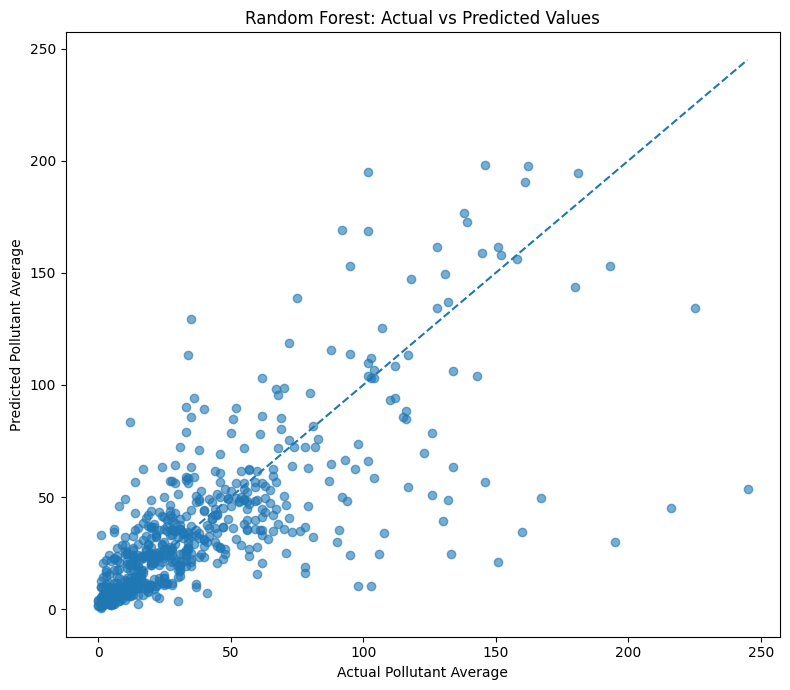


STEP 9 COMPLETED SUCCESSFULLY.


In [12]:
# ============================================
# STEP 9: MACHINE LEARNING MODEL
# SELF-CONTAINED VERSION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 70)
print("MACHINE LEARNING - POLLUTANT VALUE PREDICTION")
print("=" * 70)

# ------------------------------------------------
# 1. Reload the original dataset
# ------------------------------------------------

file_path = "/content/air_quality_data.csv.xlsx"

ml_df = pd.read_excel(file_path)

print(f"\nDataset loaded: {ml_df.shape[0]:,} rows × {ml_df.shape[1]} columns")

# Standardize column names
ml_df.columns = (
    ml_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Convert target to numeric
ml_df["pollutant_avg"] = pd.to_numeric(
    ml_df["pollutant_avg"],
    errors="coerce"
)

# Convert useful numeric columns
for col in ["latitude", "longitude", "pollutant_min", "pollutant_max"]:
    if col in ml_df.columns:
        ml_df[col] = pd.to_numeric(
            ml_df[col],
            errors="coerce"
        )

# Remove rows without target
ml_df = ml_df.dropna(
    subset=["pollutant_avg"]
).copy()

# ------------------------------------------------
# 2. Select prediction features
# ------------------------------------------------

feature_columns = [
    "pollutant_id",
    "state",
    "city",
    "station",
    "latitude",
    "longitude"
]

feature_columns = [
    col for col in feature_columns
    if col in ml_df.columns
]

X = ml_df[feature_columns].copy()
y = ml_df["pollutant_avg"].copy()

print("\nFeatures used:")
print(feature_columns)

print(f"\nRows available for modelling: {len(ml_df):,}")

# ------------------------------------------------
# 3. Identify feature types
# ------------------------------------------------

categorical_features = [
    col for col in feature_columns
    if X[col].dtype == "object"
]

numeric_features = [
    col for col in feature_columns
    if col not in categorical_features
]

# ------------------------------------------------
# 4. Preprocessing
# ------------------------------------------------

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# ------------------------------------------------
# 5. Train-test split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining records:", len(X_train))
print("Testing records :", len(X_test))

# ------------------------------------------------
# 6. Linear Regression
# ------------------------------------------------

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

# ------------------------------------------------
# 7. Random Forest
# ------------------------------------------------

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# ------------------------------------------------
# 8. Evaluation
# ------------------------------------------------

def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    r2 = r2_score(actual, predicted)

    return {
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3)
    }

results = pd.DataFrame([
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    ),
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
])

print("\n--- MODEL PERFORMANCE ---")
display(results)

# ------------------------------------------------
# 9. Actual vs predicted graph
# ------------------------------------------------

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

minimum = min(
    y_test.min(),
    rf_predictions.min()
)

maximum = max(
    y_test.max(),
    rf_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Pollutant Average")
plt.ylabel("Predicted Pollutant Average")
plt.title("Random Forest: Actual vs Predicted Values")

plt.tight_layout()
plt.show()

print("\nSTEP 9 COMPLETED SUCCESSFULLY.")

In [13]:
# ============================================
# STEP 10: MODEL RESULTS & KEY INSIGHTS
# ============================================

print("=" * 70)
print("MODEL RESULTS & KEY INSIGHTS")
print("=" * 70)

# ------------------------------------------------
# 1. Model comparison
# ------------------------------------------------

print("\n--- MODEL PERFORMANCE ---")
display(results)

# ------------------------------------------------
# 2. Identify model performance
# ------------------------------------------------

best_rmse_index = results["RMSE"].idxmin()
best_r2_index = results["R2"].idxmax()

print(
    f"\nLowest RMSE model: "
    f"{results.loc[best_rmse_index, 'Model']}"
)

print(
    f"Highest R² model: "
    f"{results.loc[best_r2_index, 'Model']}"
)

# ------------------------------------------------
# 3. Prediction examples
# ------------------------------------------------

prediction_summary = pd.DataFrame({
    "Actual Value": y_test.values,
    "Predicted Value": rf_predictions
})

prediction_summary["Absolute Error"] = (
    prediction_summary["Actual Value"]
    - prediction_summary["Predicted Value"]
).abs()

print("\n--- SAMPLE PREDICTIONS ---")
display(prediction_summary.head(10))

# ------------------------------------------------
# 4. Prediction error statistics
# ------------------------------------------------

print("\n--- PREDICTION ERROR STATISTICS ---")

display(
    prediction_summary["Absolute Error"]
    .describe()
    .to_frame("Absolute Error")
)

# ------------------------------------------------
# 5. Dataset-level insights
# ------------------------------------------------

print("\n" + "=" * 70)
print("DATA-DRIVEN INSIGHTS")
print("=" * 70)

# Most frequently observed pollutant
pollutant_counts = ml_df["pollutant_id"].value_counts()

print(
    f"\n1. Most frequently recorded pollutant: "
    f"{pollutant_counts.index[0]}"
)

# Pollutant observation counts
print("\n2. Observation count by pollutant:")
display(
    pollutant_counts
    .to_frame("Number of Records")
)

# Average pollutant values
pollutant_average = (
    ml_df
    .groupby("pollutant_id")["pollutant_avg"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("\n3. Average recorded value by pollutant:")
display(
    pollutant_average
    .to_frame("Average Recorded Value")
)

# City coverage
city_counts = ml_df["city"].value_counts()

print(
    f"\n4. Number of cities represented: "
    f"{ml_df['city'].nunique():,}"
)

print(
    f"5. Most represented city: "
    f"{city_counts.index[0]}"
)

# Station coverage
print(
    f"\n6. Number of monitoring stations: "
    f"{ml_df['station'].nunique():,}"
)

print("\nSTEP 10 COMPLETED SUCCESSFULLY.")

MODEL RESULTS & KEY INSIGHTS

--- MODEL PERFORMANCE ---


,Model,MAE,RMSE,R2
0,Linear Regression,22.206,30.064,0.401
1,Random Forest,15.079,26.534,0.533



Lowest RMSE model: Random Forest
Highest R² model: Random Forest

--- SAMPLE PREDICTIONS ---


,Actual Value,Predicted Value,Absolute Error
0,71.0,24.920,46.080
1,21.0,37.915,16.915
2,24.0,63.475,39.475
3,33.0,57.495,24.495
4,78.0,18.995,59.005
5,22.0,10.520,11.480
6,46.0,27.735,18.265
7,7.0,14.270,7.270
8,7.0,27.215,20.215
9,6.0,6.830,0.830



--- PREDICTION ERROR STATISTICS ---


...


DATA-DRIVEN INSIGHTS

1. Most frequently recorded pollutant: OZONE

2. Observation count by pollutant:


,Number of Records
pollutant_id,
OZONE,484
CO,484
NO2,468
PM2.5,454
PM10,450
SO2,437
NH3,417



3. Average recorded value by pollutant:


,Average Recorded Value
pollutant_id,
PM10,83.17
PM2.5,72.97
OZONE,38.68
CO,34.37
NO2,23.30
SO2,13.17
NH3,4.99



4. Number of cities represented: 264
5. Most represented city: Delhi

6. Number of monitoring stations: 506

STEP 10 COMPLETED SUCCESSFULLY.


In [14]:
# ============================================
# STEP 11: AI-DRIVEN INSIGHTS & DECISION SUPPORT
# ============================================

print("=" * 70)
print("AI-DRIVEN INSIGHTS & DECISION SUPPORT")
print("=" * 70)

# Create a copy for decision analysis
decision_df = ml_df.copy()

# ------------------------------------------------
# 1. Calculate pollutant-specific percentile
# ------------------------------------------------

decision_df["percentile_rank"] = (
    decision_df
    .groupby("pollutant_id")["pollutant_avg"]
    .rank(pct=True) * 100
)

# ------------------------------------------------
# 2. Assign relative level
# ------------------------------------------------

def assign_risk(percentile):

    if percentile < 50:
        return "Lower Relative Level"

    elif percentile < 75:
        return "Moderate Relative Level"

    elif percentile < 90:
        return "High Relative Level"

    else:
        return "Very High Relative Level"


decision_df["relative_risk"] = (
    decision_df["percentile_rank"]
    .apply(assign_risk)
)

# ------------------------------------------------
# 3. Overall level distribution
# ------------------------------------------------

print("\n--- RELATIVE POLLUTION LEVEL DISTRIBUTION ---")

risk_distribution = (
    decision_df["relative_risk"]
    .value_counts()
)

display(
    risk_distribution.to_frame(
        "Number of Records"
    )
)

# ------------------------------------------------
# 4. Level distribution by pollutant
# ------------------------------------------------

print("\n--- LEVEL DISTRIBUTION BY POLLUTANT ---")

risk_by_pollutant = pd.crosstab(
    decision_df["pollutant_id"],
    decision_df["relative_risk"]
)

display(risk_by_pollutant)

# ------------------------------------------------
# 5. Identify higher-level observations
# ------------------------------------------------

high_level = decision_df[
    decision_df["relative_risk"].isin([
        "High Relative Level",
        "Very High Relative Level"
    ])
].copy()

location_risk = (
    high_level
    .groupby([
        "state",
        "city",
        "pollutant_id"
    ])
    .agg(
        high_level_records=(
            "pollutant_avg",
            "count"
        ),
        average_value=(
            "pollutant_avg",
            "mean"
        ),
        maximum_value=(
            "pollutant_avg",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "high_level_records",
        ascending=False
    )
)

print("\n--- LOCATIONS WITH HIGHER RELATIVE LEVELS ---")

display(
    location_risk.head(20)
)

# ------------------------------------------------
# 6. Decision-support recommendations
# ------------------------------------------------

print("\n" + "=" * 70)
print("DECISION-SUPPORT FRAMEWORK")
print("=" * 70)

recommendations = pd.DataFrame({
    "Signal": [
        "Very High Relative Level",
        "High Relative Level",
        "Moderate Relative Level",
        "Lower Relative Level"
    ],

    "Suggested Action": [
        "Prioritize verification and investigate the monitoring location.",
        "Increase monitoring attention and investigate possible local sources.",
        "Continue routine monitoring and observe changes.",
        "Maintain routine monitoring and use as a comparison point."
    ]
})

display(recommendations)

# ------------------------------------------------
# 7. Executive insights
# ------------------------------------------------

print("\n" + "=" * 70)
print("EXECUTIVE INSIGHTS")
print("=" * 70)

most_recorded = (
    decision_df["pollutant_id"]
    .value_counts()
    .idxmax()
)

most_common_city = (
    decision_df["city"]
    .value_counts()
    .idxmax()
)

print(
    "\nMost frequently recorded pollutant:",
    most_recorded
)

print(
    "Most represented city:",
    most_common_city
)

print(
    "Number of higher-level observations:",
    len(high_level)
)

print(
    "\nInterpretation:"
)

print(
    "The relative-level framework identifies observations "
    "that are unusually high within their own pollutant "
    "distribution."
)

print(
    "These categories are analytical signals only. "
    "They are not official AQI categories or health-risk "
    "classifications."
)

print("\nSTEP 11 COMPLETED SUCCESSFULLY.")


AI-DRIVEN INSIGHTS & DECISION SUPPORT

--- RELATIVE POLLUTION LEVEL DISTRIBUTION ---


,Number of Records
relative_risk,
Lower Relative Level,1596
Moderate Relative Level,779
High Relative Level,501
Very High Relative Level,318



--- LEVEL DISTRIBUTION BY POLLUTANT ---


relative_risk,High Relative Level,Lower Relative Level,Moderate Relative Level,Very High Relative Level
pollutant_id,,,,
CO,76,241,119,48
NH3,74,222,81,40
NO2,71,233,117,47
OZONE,75,244,117,48
PM10,70,223,112,45
PM2.5,68,225,115,46
SO2,67,208,118,44



--- LOCATIONS WITH HIGHER RELATIVE LEVELS ---


,state,city,pollutant_id,high_level_records,average_value,maximum_value
56,Delhi,Delhi,PM10,40,161.600000,249.0
57,Delhi,Delhi,PM2.5,39,166.615385,255.0
54,Delhi,Delhi,NO2,27,56.407407,167.0
52,Delhi,Delhi,CO,25,63.240000,102.0
55,Delhi,Delhi,OZONE,24,94.625000,264.0
53,Delhi,Delhi,NH3,16,8.437500,15.0
58,Delhi,Delhi,SO2,12,27.833333,44.0
214,Maharashtra,Mumbai,NO2,7,41.714286,60.0
391,Uttar Pradesh,Ghaziabad,PM2.5,6,170.166667,214.0
302,Rajasthan,Jaipur,NO2,6,48.166667,81.0



DECISION-SUPPORT FRAMEWORK


,Signal,Suggested Action
0,Very High Relative Level,Prioritize verification and investigate the mo...
1,High Relative Level,Increase monitoring attention and investigate ...
2,Moderate Relative Level,Continue routine monitoring and observe changes.
3,Lower Relative Level,Maintain routine monitoring and use as a compa...



EXECUTIVE INSIGHTS

Most frequently recorded pollutant: OZONE
Most represented city: Delhi
Number of higher-level observations: 819

Interpretation:
The relative-level framework identifies observations that are unusually high within their own pollutant distribution.
These categories are analytical signals only. They are not official AQI categories or health-risk classifications.

STEP 11 COMPLETED SUCCESSFULLY.


In [15]:
# ============================================
# STEP 12: EXECUTIVE DASHBOARD & KPIs
# ============================================

print("=" * 70)
print("AIR QUALITY INTELLIGENCE - EXECUTIVE DASHBOARD")
print("=" * 70)

# ------------------------------------------------
# 1. KPI calculations
# ------------------------------------------------

total_records = len(decision_df)

total_cities = decision_df["city"].nunique()

total_states = decision_df["state"].nunique()

total_stations = decision_df["station"].nunique()

total_pollutants = decision_df["pollutant_id"].nunique()

higher_level_records = len(
    decision_df[
        decision_df["relative_risk"].isin([
            "High Relative Level",
            "Very High Relative Level"
        ])
    ]
)

# ------------------------------------------------
# 2. Display KPI summary
# ------------------------------------------------

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Observations",
        "States Covered",
        "Cities Covered",
        "Monitoring Stations",
        "Pollutant Types",
        "Higher-Level Observations"
    ],

    "Value": [
        total_records,
        total_states,
        total_cities,
        total_stations,
        total_pollutants,
        higher_level_records
    ]
})

display(kpi_summary)

# ------------------------------------------------
# 3. Pollutant summary
# ------------------------------------------------

pollutant_dashboard = (
    decision_df
    .groupby("pollutant_id")
    .agg(
        observations=("pollutant_avg", "count"),
        average_value=("pollutant_avg", "mean"),
        median_value=("pollutant_avg", "median"),
        maximum_value=("pollutant_avg", "max")
    )
    .round(2)
    .sort_values(
        "average_value",
        ascending=False
    )
)

print("\n--- POLLUTANT PERFORMANCE SUMMARY ---")

display(pollutant_dashboard)

# ------------------------------------------------
# 4. City summary
# ------------------------------------------------

city_dashboard = (
    decision_df
    .groupby("city")
    .agg(
        observations=("pollutant_avg", "count"),
        average_recorded_value=("pollutant_avg", "mean")
    )
    .round(2)
    .sort_values(
        "observations",
        ascending=False
    )
    .head(15)
)

print("\n--- TOP CITIES BY OBSERVATION COVERAGE ---")

display(city_dashboard)

# ------------------------------------------------
# 5. Higher-level locations
# ------------------------------------------------

print("\n--- PRIORITY MONITORING LOCATIONS ---")

priority_locations = (
    location_risk
    .head(10)
)

display(priority_locations)

print("\n" + "=" * 70)
print("EXECUTIVE DASHBOARD COMPLETED SUCCESSFULLY.")
print("=" * 70)

AIR QUALITY INTELLIGENCE - EXECUTIVE DASHBOARD


,KPI,Value
0,Total Observations,3194
1,States Covered,30
2,Cities Covered,264
3,Monitoring Stations,506
4,Pollutant Types,7
5,Higher-Level Observations,819



--- POLLUTANT PERFORMANCE SUMMARY ---


,observations,average_value,median_value,maximum_value
pollutant_id,,,,
PM10,450,83.17,69.0,366.0
PM2.5,454,72.97,54.0,420.0
OZONE,484,38.68,28.0,264.0
CO,484,34.37,30.0,194.0
NO2,468,23.30,20.0,167.0
SO2,437,13.17,10.0,98.0
NH3,417,4.99,4.0,29.0



--- TOP CITIES BY OBSERVATION COVERAGE ---


,observations,average_recorded_value
city,,
Delhi,287,72.81
Mumbai,148,24.97
Hyderabad,96,29.38
Ahmedabad,55,53.05
Bengaluru,52,24.08
Kolkata,49,21.10
Ghaziabad,44,68.55
Moradabad,42,44.33
Lucknow,41,38.12



--- PRIORITY MONITORING LOCATIONS ---


,state,city,pollutant_id,high_level_records,average_value,maximum_value
56,Delhi,Delhi,PM10,40,161.600000,249.0
57,Delhi,Delhi,PM2.5,39,166.615385,255.0
54,Delhi,Delhi,NO2,27,56.407407,167.0
52,Delhi,Delhi,CO,25,63.240000,102.0
55,Delhi,Delhi,OZONE,24,94.625000,264.0
53,Delhi,Delhi,NH3,16,8.437500,15.0
58,Delhi,Delhi,SO2,12,27.833333,44.0
214,Maharashtra,Mumbai,NO2,7,41.714286,60.0
391,Uttar Pradesh,Ghaziabad,PM2.5,6,170.166667,214.0
302,Rajasthan,Jaipur,NO2,6,48.166667,81.0



EXECUTIVE DASHBOARD COMPLETED SUCCESSFULLY.


FINAL ANALYTICAL VISUALIZATIONS


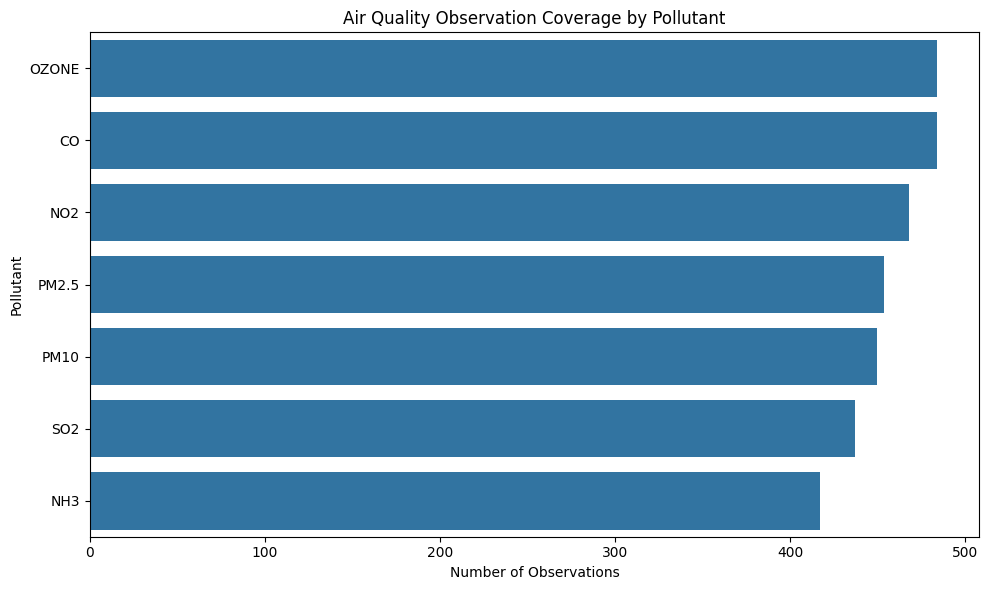

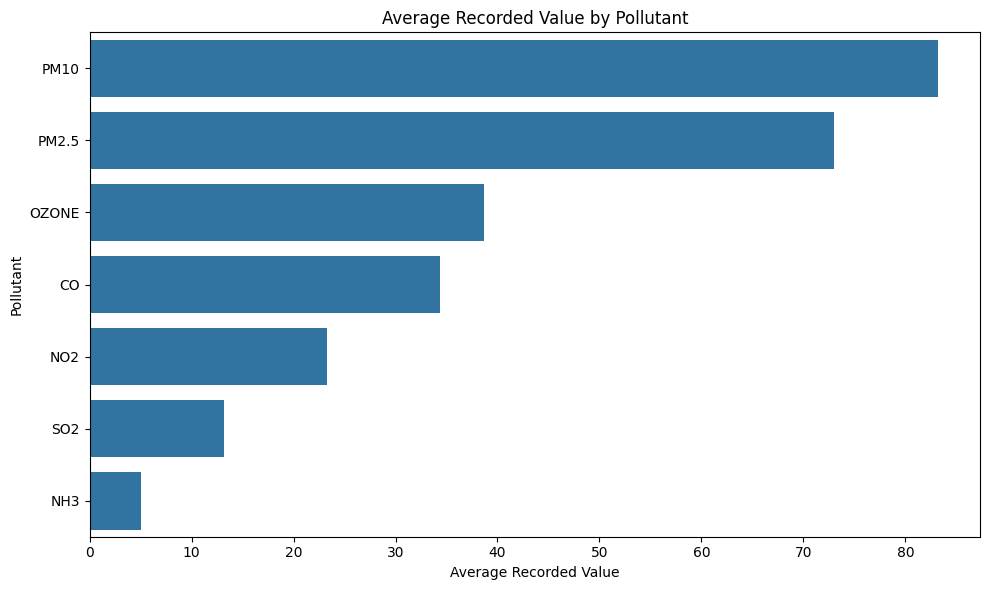

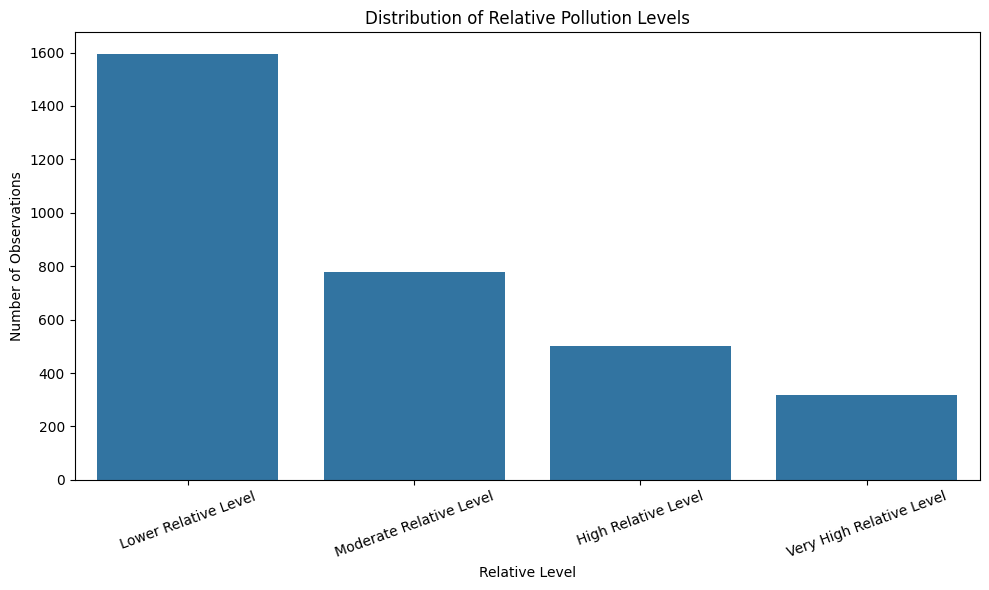

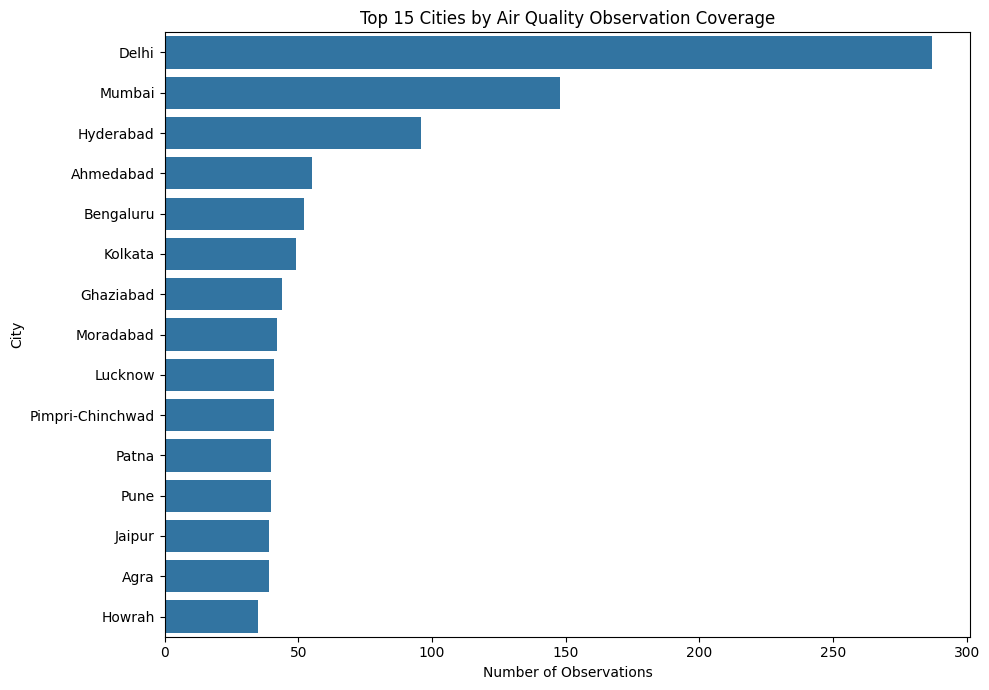

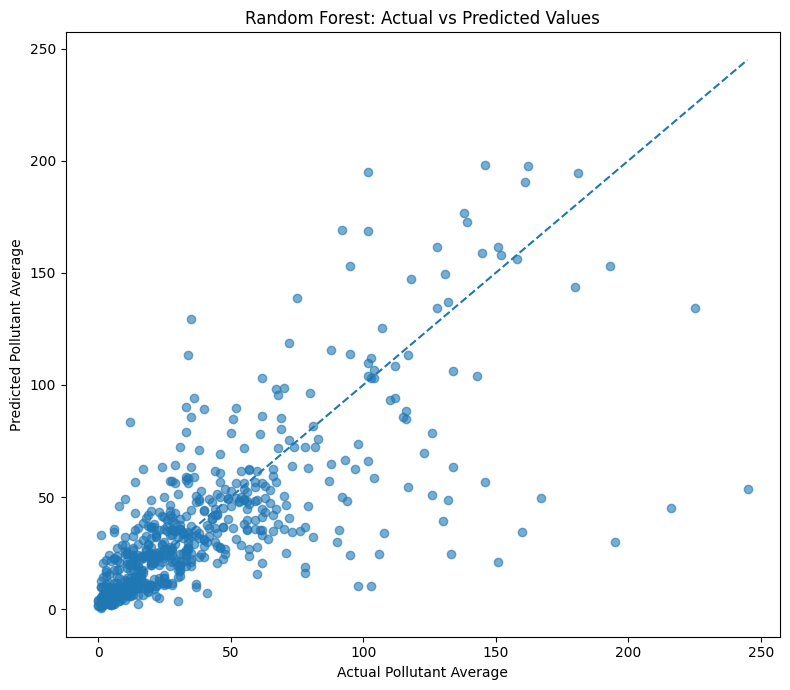


STEP 13 COMPLETED SUCCESSFULLY.


In [16]:
# ============================================
# STEP 13: FINAL ANALYTICAL VISUALIZATIONS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("FINAL ANALYTICAL VISUALIZATIONS")
print("=" * 70)

# ------------------------------------------------
# 1. Pollutant observation coverage
# ------------------------------------------------

pollutant_counts = (
    decision_df["pollutant_id"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=pollutant_counts.values,
    y=pollutant_counts.index
)

plt.title("Air Quality Observation Coverage by Pollutant")
plt.xlabel("Number of Observations")
plt.ylabel("Pollutant")
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 2. Average value by pollutant
# ------------------------------------------------

pollutant_means = (
    decision_df
    .groupby("pollutant_id")["pollutant_avg"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=pollutant_means.values,
    y=pollutant_means.index
)

plt.title("Average Recorded Value by Pollutant")
plt.xlabel("Average Recorded Value")
plt.ylabel("Pollutant")
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 3. Relative-level distribution
# ------------------------------------------------

risk_counts = (
    decision_df["relative_risk"]
    .value_counts()
)

risk_order = [
    "Lower Relative Level",
    "Moderate Relative Level",
    "High Relative Level",
    "Very High Relative Level"
]

risk_counts = risk_counts.reindex(
    risk_order
).fillna(0)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Distribution of Relative Pollution Levels")
plt.xlabel("Relative Level")
plt.ylabel("Number of Observations")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 4. Top cities by observation coverage
# ------------------------------------------------

top_cities = (
    decision_df["city"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 15 Cities by Air Quality Observation Coverage")
plt.xlabel("Number of Observations")
plt.ylabel("City")
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 5. Actual vs predicted model performance
# ------------------------------------------------

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

minimum = min(
    y_test.min(),
    rf_predictions.min()
)

maximum = max(
    y_test.max(),
    rf_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title("Random Forest: Actual vs Predicted Values")
plt.xlabel("Actual Pollutant Average")
plt.ylabel("Predicted Pollutant Average")
plt.tight_layout()
plt.show()


print("\nSTEP 13 COMPLETED SUCCESSFULLY.")


In [17]:
# ============================================
# STEP 14: SAVE PROJECT OUTPUTS
# ============================================

import os
import pandas as pd

print("=" * 70)
print("SAVING PROJECT OUTPUTS")
print("=" * 70)

# Create output folder
os.makedirs("/content/project_outputs", exist_ok=True)

# ------------------------------------------------
# 1. Save cleaned dataset
# ------------------------------------------------

clean_output = "/content/project_outputs/cleaned_air_quality_data.csv"

decision_df.to_csv(
    clean_output,
    index=False
)

print("\n1. Cleaned dataset saved:")
print(clean_output)

# ------------------------------------------------
# 2. Save model comparison
# ------------------------------------------------

model_output = "/content/project_outputs/model_comparison.csv"

results.to_csv(
    model_output,
    index=False
)

print("\n2. Model comparison saved:")
print(model_output)

# ------------------------------------------------
# 3. Save pollutant summary
# ------------------------------------------------

pollutant_output = "/content/project_outputs/pollutant_summary.csv"

pollutant_dashboard.to_csv(
    pollutant_output
)

print("\n3. Pollutant summary saved:")
print(pollutant_output)

# ------------------------------------------------
# 4. Save priority locations
# ------------------------------------------------

location_output = "/content/project_outputs/priority_locations.csv"

priority_locations.to_csv(
    location_output,
    index=False
)

print("\n4. Priority locations saved:")
print(location_output)

# ------------------------------------------------
# 5. Save KPI summary
# ------------------------------------------------

kpi_output = "/content/project_outputs/kpi_summary.csv"

kpi_summary.to_csv(
    kpi_output,
    index=False
)

print("\n5. KPI summary saved:")
print(kpi_output)

# ------------------------------------------------
# 6. List generated files
# ------------------------------------------------

print("\n" + "=" * 70)
print("GENERATED PROJECT OUTPUTS")
print("=" * 70)

for file in os.listdir("/content/project_outputs"):
    print("✓", file)

print("\nSTEP 14 COMPLETED SUCCESSFULLY.")

SAVING PROJECT OUTPUTS

1. Cleaned dataset saved:
/content/project_outputs/cleaned_air_quality_data.csv

2. Model comparison saved:
/content/project_outputs/model_comparison.csv

3. Pollutant summary saved:
/content/project_outputs/pollutant_summary.csv

4. Priority locations saved:
/content/project_outputs/priority_locations.csv

5. KPI summary saved:
/content/project_outputs/kpi_summary.csv

GENERATED PROJECT OUTPUTS
✓ kpi_summary.csv
✓ priority_locations.csv
✓ model_comparison.csv
✓ cleaned_air_quality_data.csv
✓ pollutant_summary.csv

STEP 14 COMPLETED SUCCESSFULLY.
